# 05 - Klasifikasi CNN: Baseline Original vs GrabCut

## 1. Import Library

In [1]:
import os
import warnings
from pathlib import Path

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

try:
    tf.config.set_visible_devices([], "GPU")
except RuntimeError as exc:
    print("Device TensorFlow sudah aktif:", exc)

print("TensorFlow:", tf.__version__)
print("Device mode: CPU-only")

TensorFlow: 2.21.0
Device mode: CPU-only


## 2. Konfigurasi Parameter

In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS = 20

# Reproducibility
tf.keras.utils.set_random_seed(SEED)

PROJECT_ROOT = Path("..").resolve()

# Folder dataset 
DIR_ORIGINAL = PROJECT_ROOT / "data" / "split"
DIR_GRABCUT = PROJECT_ROOT / "data" / "segmented_grabcut"

# Folder output 
DIR_MODELS = PROJECT_ROOT / "models"
DIR_RESULTS = PROJECT_ROOT / "results" / "cnn"
DIR_MODELS.mkdir(parents=True, exist_ok=True)
DIR_RESULTS.mkdir(parents=True, exist_ok=True)

EXPECTED_CLASSES = ["biological", "cardboard", "glass", "metal", "paper", "plastic"]
NUM_CLASSES = len(EXPECTED_CLASSES)

print("Original dataset:", DIR_ORIGINAL)
print("GrabCut dataset :", DIR_GRABCUT)
print("Models  ->", DIR_MODELS)
print("Results ->", DIR_RESULTS)

Original dataset: C:\Users\User\Downloads\Waste Classification - PCD Project\data\split
GrabCut dataset : C:\Users\User\Downloads\Waste Classification - PCD Project\data\segmented_grabcut
Models  -> C:\Users\User\Downloads\Waste Classification - PCD Project\models
Results -> C:\Users\User\Downloads\Waste Classification - PCD Project\results\cnn


## 3. Load Dataset + Validasi

In [3]:
def cek_folder_dataset(base_dir):
    if not base_dir.exists():
        raise FileNotFoundError(
            f"Folder dataset tidak ditemukan: {base_dir}\n"
            f"Pastikan path benar dan dataset sudah tersedia."
        )
    for split in ["train", "val", "test"]:
        if not (base_dir / split).exists():
            raise FileNotFoundError(
                f"Subfolder '{split}' tidak ditemukan di {base_dir}"
            )


def load_split(base_dir, split, shuffle):
   
    return tf.keras.utils.image_dataset_from_directory(
        base_dir / split,
        labels="inferred",
        label_mode="int",
        class_names=None,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=SEED,
    )


def load_dataset(base_dir, nama):
    
    cek_folder_dataset(base_dir)
    ds_train = load_split(base_dir, "train", shuffle=True)
    ds_val = load_split(base_dir, "val", shuffle=False)
    ds_test = load_split(base_dir, "test", shuffle=False)

    class_names = ds_train.class_names
    print(f"[{nama}] class_names: {class_names}")
    if len(class_names) != NUM_CLASSES:
        warnings.warn(
            f"[{nama}] jumlah kelas = {len(class_names)}, "
            f"diharapkan {NUM_CLASSES}!"
        )
    return ds_train, ds_val, ds_test, class_names

In [4]:
# Load dataset ORIGINAL
dataset_original_train, dataset_original_val, dataset_original_test, classes_original = \
    load_dataset(DIR_ORIGINAL, "ORIGINAL")

Found 5396 files belonging to 6 classes.
Found 1156 files belonging to 6 classes.
Found 1157 files belonging to 6 classes.
[ORIGINAL] class_names: ['biological', 'cardboard', 'glass', 'metal', 'paper', 'plastic']


In [5]:
# Load dataset GRABCUT
dataset_grabcut_train, dataset_grabcut_val, dataset_grabcut_test, classes_grabcut = \
    load_dataset(DIR_GRABCUT, "GRABCUT")

Found 5396 files belonging to 6 classes.
Found 1156 files belonging to 6 classes.
Found 1157 files belonging to 6 classes.
[GRABCUT] class_names: ['biological', 'cardboard', 'glass', 'metal', 'paper', 'plastic']


## 4. Konsistensi Urutan Kelas

In [6]:
print("Original:", classes_original)
print("GrabCut :", classes_grabcut)

if classes_original == classes_grabcut:
    CLASS_NAMES = classes_original
    print("\nOK - urutan kelas kedua dataset SAMA. Label konsisten.")
else:
    raise ValueError(
        "Urutan kelas berbeda antara original dan GrabCut!\n"
        f"  original: {classes_original}\n  grabcut : {classes_grabcut}\n"
        "Samakan nama/struktur folder agar label konsisten."
    )

print("CLASS_NAMES yang dipakai:", CLASS_NAMES)

Original: ['biological', 'cardboard', 'glass', 'metal', 'paper', 'plastic']
GrabCut : ['biological', 'cardboard', 'glass', 'metal', 'paper', 'plastic']

OK - urutan kelas kedua dataset SAMA. Label konsisten.
CLASS_NAMES yang dipakai: ['biological', 'cardboard', 'glass', 'metal', 'paper', 'plastic']


## 5. Optimasi Pipeline (cache + prefetch)

In [7]:
AUTOTUNE = tf.data.AUTOTUNE


def optimasi(ds):
    return ds.cache().prefetch(buffer_size=AUTOTUNE)


dataset_original_train = optimasi(dataset_original_train)
dataset_original_val = optimasi(dataset_original_val)
dataset_original_test = optimasi(dataset_original_test)

dataset_grabcut_train = optimasi(dataset_grabcut_train)
dataset_grabcut_val = optimasi(dataset_grabcut_val)
dataset_grabcut_test = optimasi(dataset_grabcut_test)
print("Pipeline dataset siap (cache + prefetch).")

Pipeline dataset siap (cache + prefetch).


## 6. Visualisasi Sample Dataset

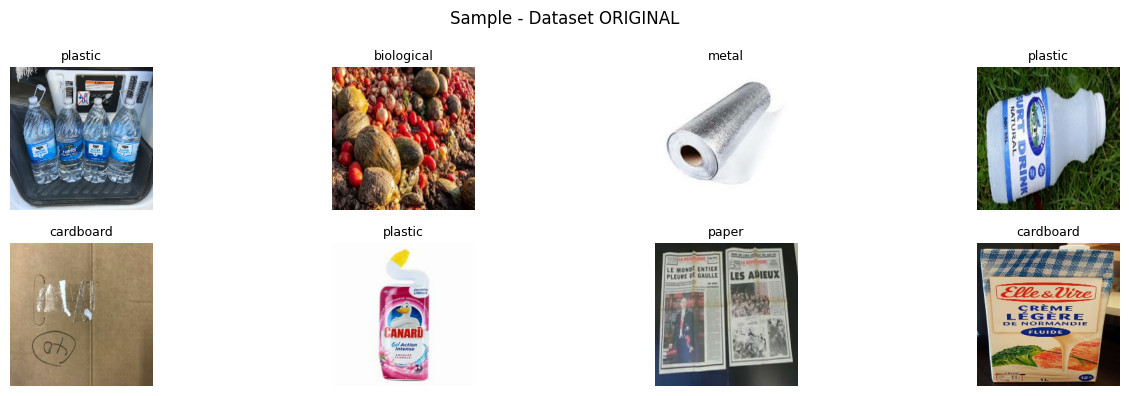

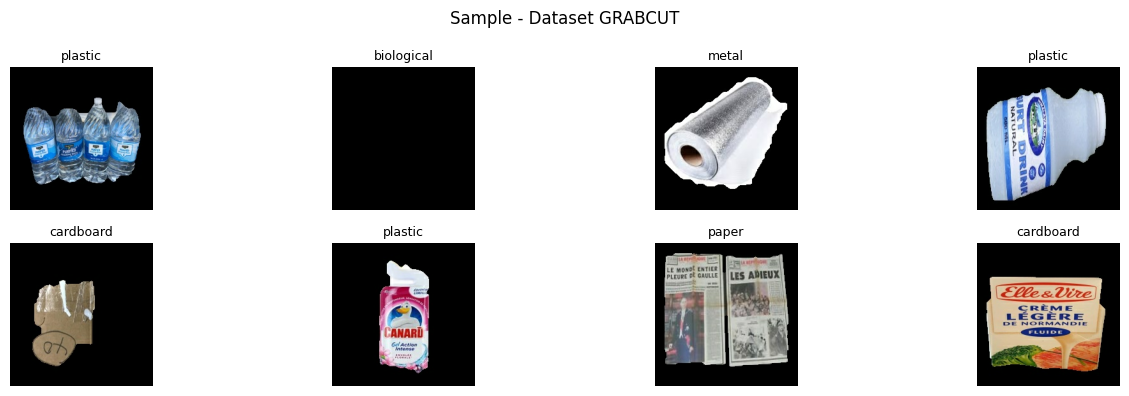

In [8]:
def tampilkan_sample(ds, class_names, judul, n=8):
    plt.figure(figsize=(14, 4))
    for gambar_batch, label_batch in ds.take(1):
        for i in range(min(n, gambar_batch.shape[0])):
            ax = plt.subplot(2, n // 2, i + 1)
            plt.imshow(gambar_batch[i].numpy().astype("uint8"))
            plt.title(class_names[int(label_batch[i])], fontsize=9)
            plt.axis("off")
    plt.suptitle(judul)
    plt.tight_layout()
    plt.show()


tampilkan_sample(dataset_original_train, CLASS_NAMES, "Sample - Dataset ORIGINAL")
tampilkan_sample(dataset_grabcut_train, CLASS_NAMES, "Sample - Dataset GRABCUT")

## 7.  Arsitektur CNN

In [9]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal", seed=SEED),
        layers.RandomRotation(0.1, seed=SEED),
        layers.RandomZoom(0.1, seed=SEED),
    ],
    name="data_augmentation",
)


def build_cnn_model(num_classes=NUM_CLASSES, input_shape=IMG_SIZE + (3,)):

    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)              # aktif hanya saat training
    x = layers.Rescaling(1.0 / 255)(x)         # 0-255 -> 0-1

    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="cnn_baseline")
    model.compile(
        optimizer=keras.optimizers.Adam(),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )
    return model


# Tampilkan ringkasan arsitektur (sekali)
build_cnn_model().summary()

Model: "cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,534 (431.77 KB)

 Trainable params: 110,534 (431.77 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Fungsi Training Reusable + Callbacks

Callback :

* **EarlyStopping** (`monitor='val_loss'`, `patience=5`, `restore_best_weights=True`),
* **ModelCheckpoint** menyimpan model terbaik berdasarkan `val_loss`.

In [10]:
def latih_model(ds_train, ds_val, nama_file_model, judul):
    tf.keras.utils.set_random_seed(SEED)   # bobot awal & augmentasi konsisten
    model = build_cnn_model()

    path_model = DIR_MODELS / nama_file_model
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=5, restore_best_weights=True
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=str(path_model), monitor="val_loss",
            save_best_only=True, verbose=0
        ),
    ]

    print(f"\nTraining: {judul}")
    history = model.fit(
        ds_train,
        validation_data=ds_val,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1,
    )
    model.save(path_model)
    print(f"Model disimpan ke: {path_model}")
    return model, history

## 9. Training CNN pada Dataset ORIGINAL

In [11]:
model_original, history_original = latih_model(
    dataset_original_train,
    dataset_original_val,
    nama_file_model="cnn_original_baseline.keras",
    judul="ORIGINAL",
)


Training: ORIGINAL
Epoch 1/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 121s 689ms/step - accuracy: 0.2607 - loss: 1.6855 - val_accuracy: 0.3149 - val_loss: 1.6022
Epoch 2/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 106s 626ms/step - accuracy: 0.3395 - loss: 1.5917 - val_accuracy: 0.3235 - val_loss: 1.5949
Epoch 3/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 110s 652ms/step - accuracy: 0.3599 - loss: 1.5414 - val_accuracy: 0.3798 - val_loss: 1.5294
Epoch 4/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 105s 623ms/step - accuracy: 0.3988 - loss: 1.4927 - val_accuracy: 0.3754 - val_loss: 1.5096
Epoch 5/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 104s 615ms/step - accuracy: 0.4350 - loss: 1.4346 - val_accuracy: 0.4628 - val_loss: 1.4421
Epoch 6/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 104s 618ms/step - accuracy: 0.4707 - loss: 1.3608 - val_accuracy: 0.4619 - val_loss: 1.4755
Epoch 7/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 104s 614ms/step - accuracy: 0.5057 - loss: 1.3081 - val_accuracy: 0.4853 - val_loss: 1.3874
Epoch 8/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 102s 602ms/step 

## 10. Training CNN pada Dataset GRABCUT

In [12]:
model_grabcut, history_grabcut = latih_model(
    dataset_grabcut_train,
    dataset_grabcut_val,
    nama_file_model="cnn_grabcut.keras",
    judul="GRABCUT",
)


Training: GRABCUT
Epoch 1/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 116s 674ms/step - accuracy: 0.2913 - loss: 1.6836 - val_accuracy: 0.3443 - val_loss: 1.6123
Epoch 2/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 104s 613ms/step - accuracy: 0.3673 - loss: 1.5707 - val_accuracy: 0.3780 - val_loss: 1.5475
Epoch 3/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 105s 620ms/step - accuracy: 0.3905 - loss: 1.5171 - val_accuracy: 0.3737 - val_loss: 1.5295
Epoch 4/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 112s 660ms/step - accuracy: 0.4122 - loss: 1.4893 - val_accuracy: 0.3927 - val_loss: 1.4825
Epoch 5/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 104s 616ms/step - accuracy: 0.4231 - loss: 1.4686 - val_accuracy: 0.4187 - val_loss: 1.4648
Epoch 6/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 105s 620ms/step - accuracy: 0.4351 - loss: 1.4324 - val_accuracy: 0.4446 - val_loss: 1.4159
Epoch 7/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 105s 620ms/step - accuracy: 0.4444 - loss: 1.4118 - val_accuracy: 0.4481 - val_loss: 1.4038
Epoch 8/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 103s 612ms/step -

## 11. Grafik Training History

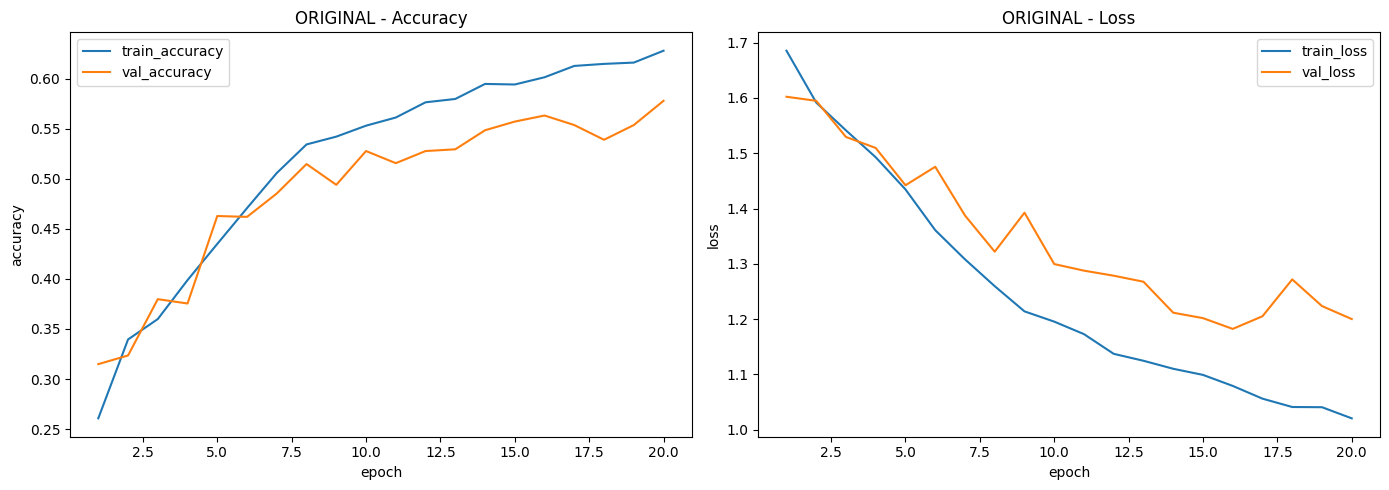

Disimpan: C:\Users\User\Downloads\Waste Classification - PCD Project\results\cnn\training_history_original.png


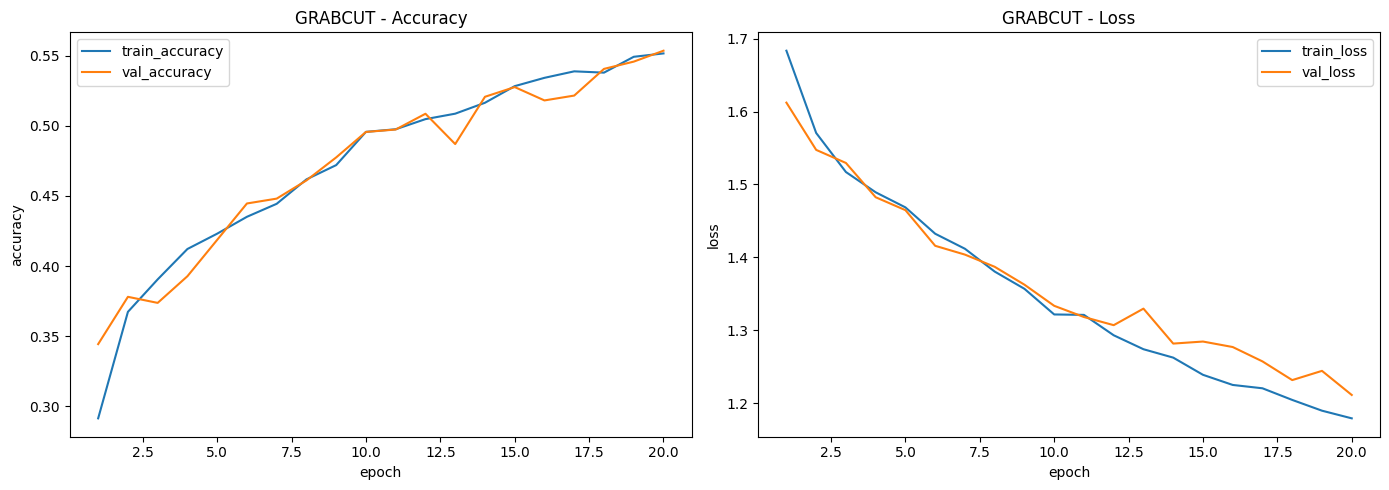

Disimpan: C:\Users\User\Downloads\Waste Classification - PCD Project\results\cnn\training_history_grabcut.png


In [13]:
def plot_history(history, judul, nama_file):
    h = history.history
    epochs_range = range(1, len(h["loss"]) + 1)

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    ax[0].plot(epochs_range, h["accuracy"], label="train_accuracy")
    ax[0].plot(epochs_range, h["val_accuracy"], label="val_accuracy")
    ax[0].set_title(f"{judul} - Accuracy")
    ax[0].set_xlabel("epoch"); ax[0].set_ylabel("accuracy"); ax[0].legend()

    ax[1].plot(epochs_range, h["loss"], label="train_loss")
    ax[1].plot(epochs_range, h["val_loss"], label="val_loss")
    ax[1].set_title(f"{judul} - Loss")
    ax[1].set_xlabel("epoch"); ax[1].set_ylabel("loss"); ax[1].legend()

    plt.tight_layout()
    path = DIR_RESULTS / nama_file
    plt.savefig(path, dpi=120, bbox_inches="tight")
    plt.show()
    print("Disimpan:", path)


plot_history(history_original, "ORIGINAL", "training_history_original.png")
plot_history(history_grabcut, "GRABCUT", "training_history_grabcut.png")

## 12. Evaluasi pada Test Set

In [14]:
def kumpulkan_prediksi(model, ds):
    """Kembalikan (y_true, y_pred, y_conf) dari sebuah dataset (tanpa shuffle)."""
    y_true, y_pred, y_conf = [], [], []
    for gambar_batch, label_batch in ds:
        probs = model.predict(gambar_batch, verbose=0)
        pred = np.argmax(probs, axis=1)
        conf = np.max(probs, axis=1)
        y_true.extend(label_batch.numpy().tolist())
        y_pred.extend(pred.tolist())
        y_conf.extend(conf.tolist())
    return np.array(y_true), np.array(y_pred), np.array(y_conf)


def evaluasi_model(model, ds_test, nama_model, nama_dataset):
    test_loss, test_acc = model.evaluate(ds_test, verbose=0)
    y_true, y_pred, _ = kumpulkan_prediksi(model, ds_test)

    p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    p_w, r_w, f_w, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    hasil = {
        "model_name": nama_model,
        "dataset": nama_dataset,
        "test_loss": round(float(test_loss), 4),
        "test_accuracy": round(float(test_acc), 4),
        "precision_macro": round(float(p_macro), 4),
        "recall_macro": round(float(r_macro), 4),
        "f1_macro": round(float(f_macro), 4),
        "precision_weighted": round(float(p_w), 4),
        "recall_weighted": round(float(r_w), 4),
        "f1_weighted": round(float(f_w), 4),
    }
    return hasil, y_true, y_pred


hasil_original, ytrue_ori, ypred_ori = evaluasi_model(
    model_original, dataset_original_test, "cnn_original_baseline", "original"
)
hasil_grabcut, ytrue_gc, ypred_gc = evaluasi_model(
    model_grabcut, dataset_grabcut_test, "cnn_grabcut", "grabcut"
)

print("ORIGINAL:", hasil_original)
print("GRABCUT :", hasil_grabcut)

ORIGINAL: {'model_name': 'cnn_original_baseline', 'dataset': 'original', 'test_loss': 1.1145, 'test_accuracy': 0.5661, 'precision_macro': 0.5789, 'recall_macro': 0.5731, 'f1_macro': 0.5709, 'precision_weighted': 0.5811, 'recall_weighted': 0.5661, 'f1_weighted': 0.5676}
GRABCUT : {'model_name': 'cnn_grabcut', 'dataset': 'grabcut', 'test_loss': 1.18, 'test_accuracy': 0.548, 'precision_macro': 0.5536, 'recall_macro': 0.5401, 'f1_macro': 0.5448, 'precision_weighted': 0.5559, 'recall_weighted': 0.548, 'f1_weighted': 0.5507}


## 13. Confusion Matrix

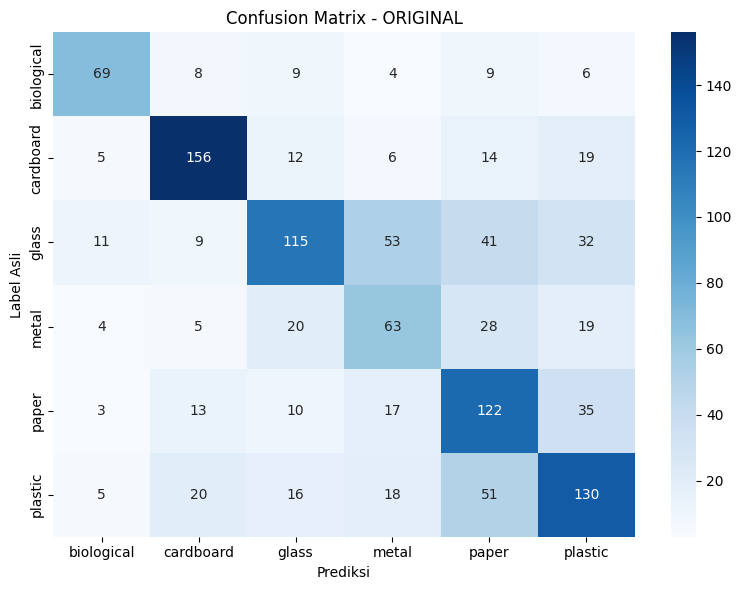

Disimpan: C:\Users\User\Downloads\Waste Classification - PCD Project\results\cnn\confusion_matrix_original.png


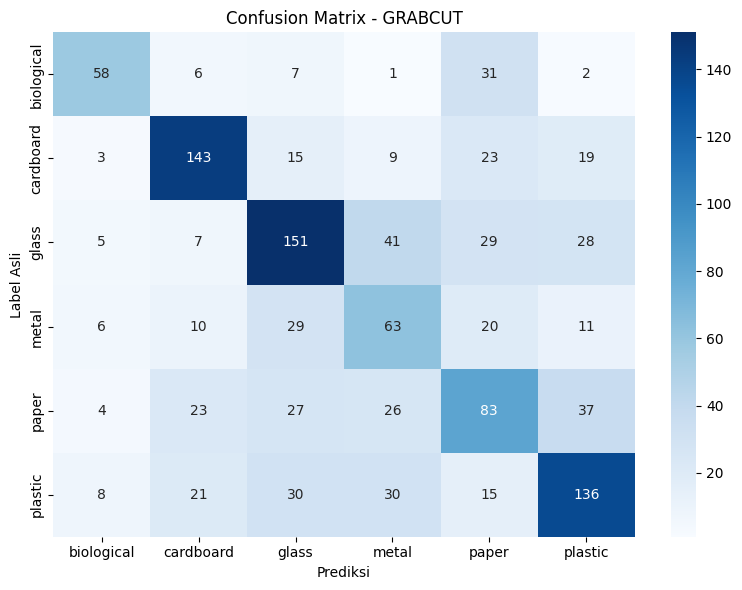

Disimpan: C:\Users\User\Downloads\Waste Classification - PCD Project\results\cnn\confusion_matrix_grabcut.png


In [15]:
def plot_confusion(y_true, y_pred, class_names, judul, nama_file):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names,
    )
    plt.title(judul)
    plt.xlabel("Prediksi"); plt.ylabel("Label Asli")
    plt.tight_layout()
    path = DIR_RESULTS / nama_file
    plt.savefig(path, dpi=120, bbox_inches="tight")
    plt.show()
    print("Disimpan:", path)
    return cm


cm_original = plot_confusion(
    ytrue_ori, ypred_ori, CLASS_NAMES,
    "Confusion Matrix - ORIGINAL", "confusion_matrix_original.png"
)
cm_grabcut = plot_confusion(
    ytrue_gc, ypred_gc, CLASS_NAMES,
    "Confusion Matrix - GRABCUT", "confusion_matrix_grabcut.png"
)

## 14. Classification Report (disimpan ke CSV)

In [16]:
def simpan_classification_report(y_true, y_pred, class_names, nama_file):
    report_dict = classification_report(
        y_true, y_pred, labels=range(len(class_names)),
        target_names=class_names, output_dict=True, zero_division=0,
    )
    df = pd.DataFrame(report_dict).transpose()
    path = DIR_RESULTS / nama_file
    df.to_csv(path)
    print("Disimpan:", path)
    return df


print("Classification Report - ORIGINAL")
df_report_original = simpan_classification_report(
    ytrue_ori, ypred_ori, CLASS_NAMES, "classification_report_original.csv"
)
display(df_report_original.round(3))

print("\nClassification Report - GRABCUT")
df_report_grabcut = simpan_classification_report(
    ytrue_gc, ypred_gc, CLASS_NAMES, "classification_report_grabcut.csv"
)
display(df_report_grabcut.round(3))

Classification Report - ORIGINAL
Disimpan: C:\Users\User\Downloads\Waste Classification - PCD Project\results\cnn\classification_report_original.csv


,precision,recall,f1-score,support
biological,0.711,0.657,0.683,105.000
cardboard,0.739,0.736,0.738,212.000
glass,0.632,0.441,0.519,261.000
metal,0.391,0.453,0.420,139.000
paper,0.460,0.610,0.525,200.000
plastic,0.539,0.542,0.541,240.000
accuracy,0.566,0.566,0.566,0.566
macro avg,0.579,0.573,0.571,1157.000
weighted avg,0.581,0.566,0.568,1157.000



Classification Report - GRABCUT
Disimpan: C:\Users\User\Downloads\Waste Classification - PCD Project\results\cnn\classification_report_grabcut.csv


,precision,recall,f1-score,support
biological,0.690,0.552,0.614,105.000
cardboard,0.681,0.675,0.678,212.000
glass,0.583,0.579,0.581,261.000
metal,0.371,0.453,0.408,139.000
paper,0.413,0.415,0.414,200.000
plastic,0.584,0.567,0.575,240.000
accuracy,0.548,0.548,0.548,0.548
macro avg,0.554,0.540,0.545,1157.000
weighted avg,0.556,0.548,0.551,1157.000


## 15. Tabel Perbandingan Model

Gabungkan metrik kedua model ke satu DataFrame dan simpan sebagai CSV.

In [17]:
df_perbandingan = pd.DataFrame([hasil_original, hasil_grabcut])
kolom = [
    "model_name", "dataset", "test_loss", "test_accuracy",
    "precision_macro", "recall_macro", "f1_macro",
    "precision_weighted", "recall_weighted", "f1_weighted",
]
df_perbandingan = df_perbandingan[kolom]

path_comp = DIR_RESULTS / "model_comparison_original_vs_grabcut.csv"
df_perbandingan.to_csv(path_comp, index=False)
print("Disimpan:", path_comp)
display(df_perbandingan)

Disimpan: C:\Users\User\Downloads\Waste Classification - PCD Project\results\cnn\model_comparison_original_vs_grabcut.csv


,model_name,dataset,test_loss,test_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,cnn_original_baseline,original,1.1145,0.5661,0.5789,0.5731,0.5709,0.5811,0.5661,0.5676
1,cnn_grabcut,grabcut,1.1800,0.5480,0.5536,0.5401,0.5448,0.5559,0.5480,0.5507


## 16. Visualisasi Prediksi

Beberapa gambar dari test set per model: gambar input, label asli, label prediksi,
dan confidence. Judul **hijau = benar**, **merah = salah**.

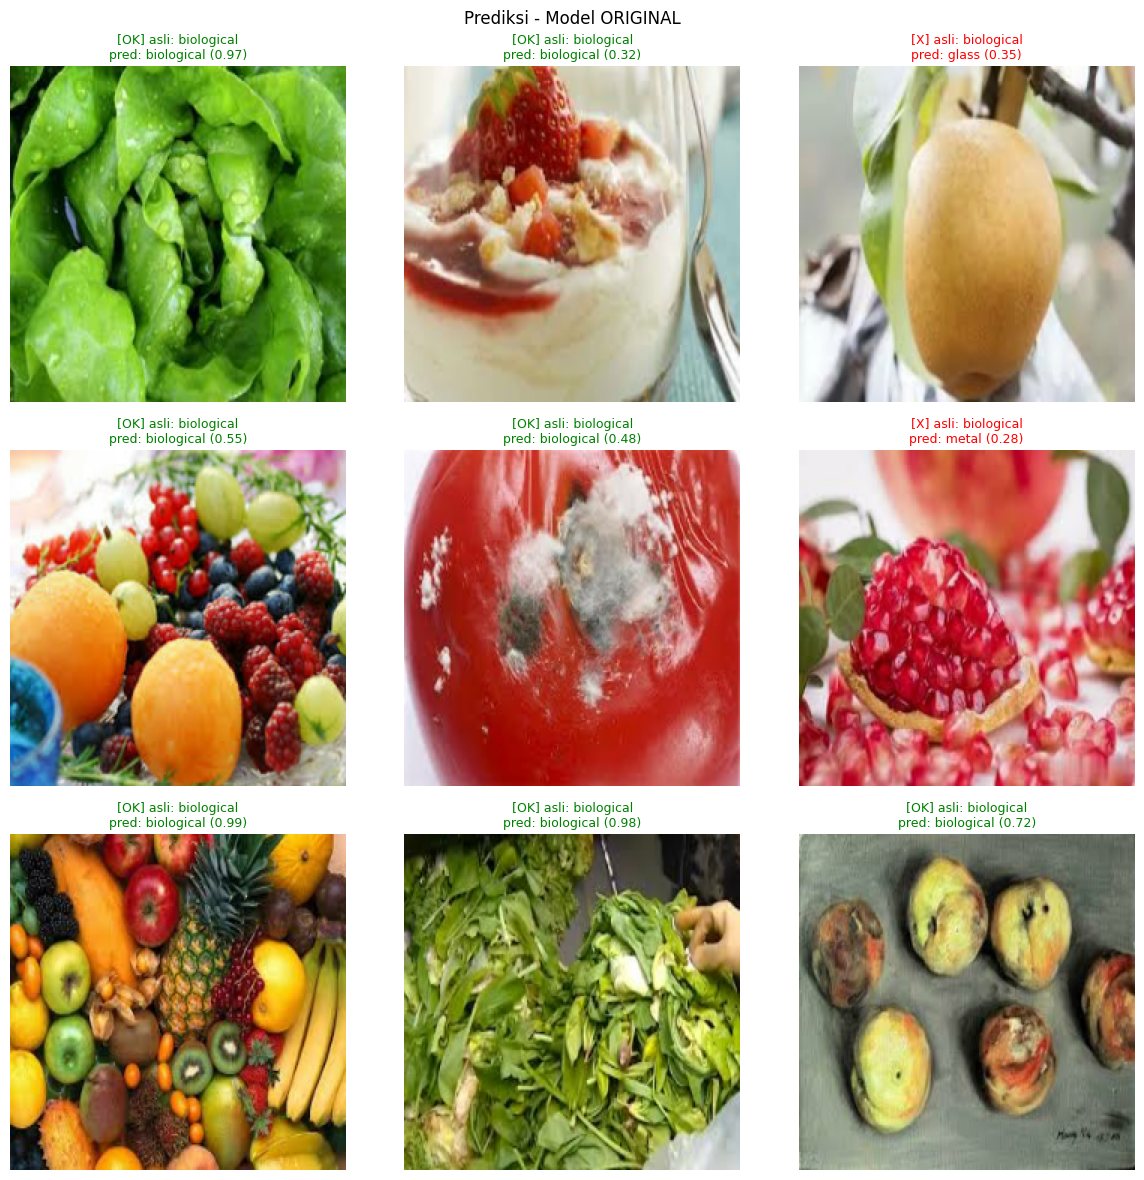

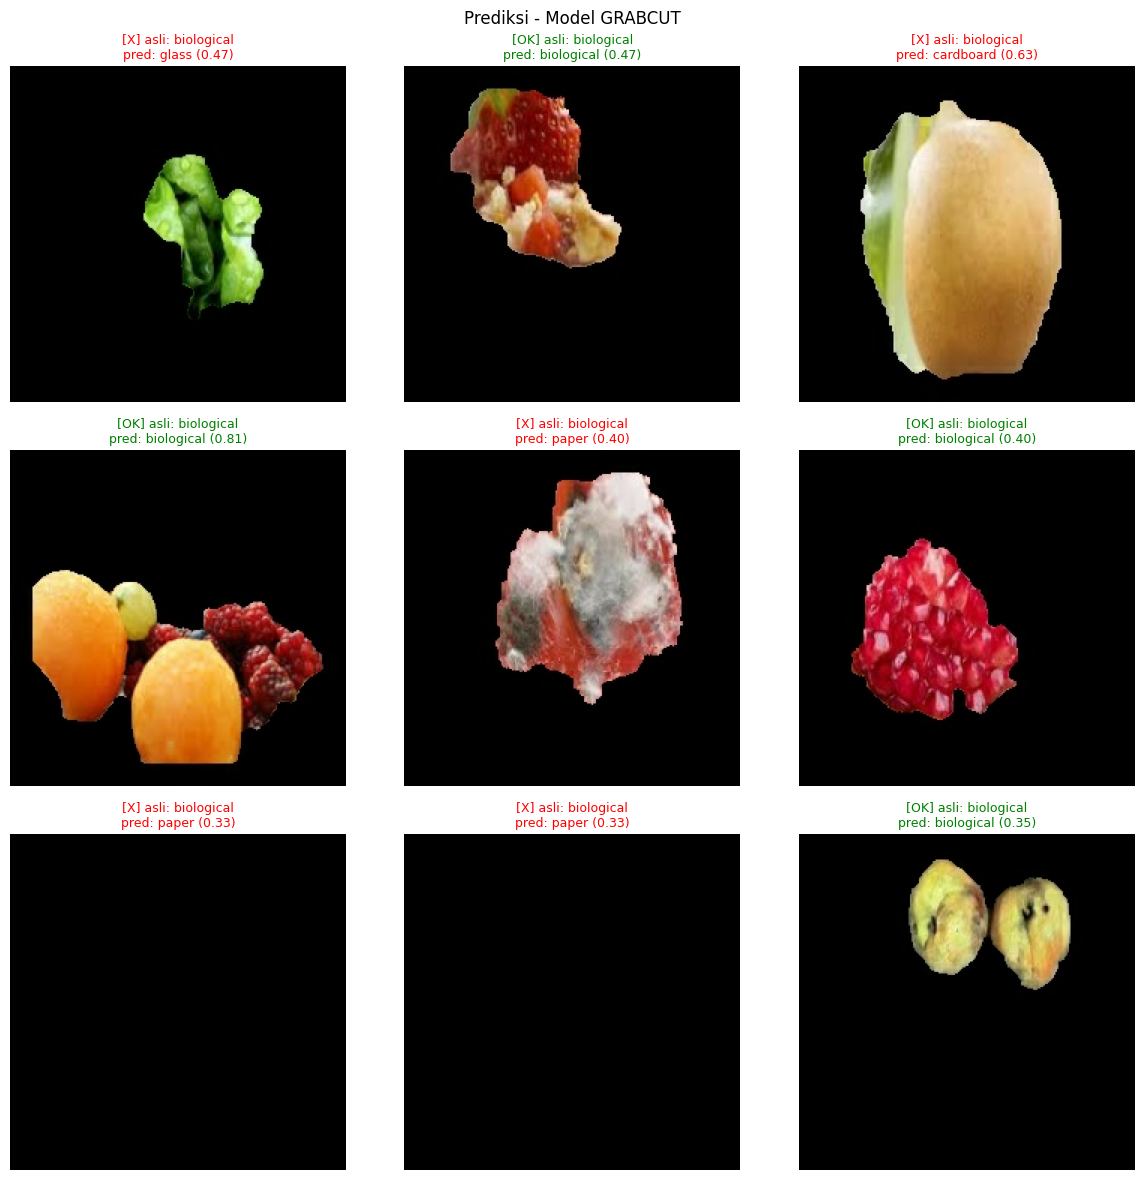

In [18]:
def visualisasi_prediksi(model, ds_test, class_names, judul, n=9):
    # Ambil satu batch dari test set
    for gambar_batch, label_batch in ds_test.take(1):
        probs = model.predict(gambar_batch, verbose=0)
        pred = np.argmax(probs, axis=1)
        conf = np.max(probs, axis=1)

        plt.figure(figsize=(12, 12))
        for i in range(min(n, gambar_batch.shape[0])):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(gambar_batch[i].numpy().astype("uint8"))
            asli = class_names[int(label_batch[i])]
            prediksi = class_names[int(pred[i])]
            benar = int(label_batch[i]) == int(pred[i])
            warna = "green" if benar else "red"
            tanda = "OK" if benar else "X"
            ax.set_title(
                f"[{tanda}] asli: {asli}\npred: {prediksi} ({conf[i]:.2f})",
                color=warna, fontsize=9,
            )
            plt.axis("off")
        plt.suptitle(judul)
        plt.tight_layout()
        plt.show()
        break


visualisasi_prediksi(model_original, dataset_original_test, CLASS_NAMES,
                     "Prediksi - Model ORIGINAL")
visualisasi_prediksi(model_grabcut, dataset_grabcut_test, CLASS_NAMES,
                     "Prediksi - Model GRABCUT")

In [19]:
def kelas_paling_salah(cm, class_names):
    cm_off = cm.copy()
    np.fill_diagonal(cm_off, 0)
    if cm_off.sum() == 0:
        return None
    i, j = np.unravel_index(np.argmax(cm_off), cm_off.shape)
    return class_names[i], class_names[j], int(cm_off[i, j])


for nama, cm in [("ORIGINAL", cm_original), ("GRABCUT", cm_grabcut)]:
    info = kelas_paling_salah(cm, CLASS_NAMES)
    if info:
        print(f"[{nama}] paling sering salah: '{info[0]}' diprediksi sebagai "
              f"'{info[1]}' sebanyak {info[2]} kali")
    else:
        print(f"[{nama}] tidak ada kesalahan klasifikasi.")

# Akurasi per kelas (recall) untuk melihat kelas terlemah
print("\nRecall per kelas (akurasi per kelas):")
for nama, cm in [("ORIGINAL", cm_original), ("GRABCUT", cm_grabcut)]:
    recall_kelas = cm.diagonal() / cm.sum(axis=1).clip(min=1)
    terlemah = CLASS_NAMES[int(np.argmin(recall_kelas))]
    print(f"  [{nama}] kelas terlemah: {terlemah} "
          f"(recall={recall_kelas.min():.2f})")

[ORIGINAL] paling sering salah: 'glass' diprediksi sebagai 'metal' sebanyak 53 kali
[GRABCUT] paling sering salah: 'glass' diprediksi sebagai 'metal' sebanyak 41 kali

Recall per kelas (akurasi per kelas):
  [ORIGINAL] kelas terlemah: glass (recall=0.44)
  [GRABCUT] kelas terlemah: paper (recall=0.41)
